In [ ]:
import os
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use('bmh')

In [37]:
ruta = "/Users/andresitoortiz/Library/Mobile Documents/com~apple~CloudDocs/Pregrado_Fisica/2025-2/Lab_intermedio/Franck-Hertz/FranckHertz/Actividad_1"
data = {}
for archivo in glob.glob(os.path.join(ruta, "*.csv")):
    nombre = os.path.basename(archivo)
    df = pd.read_csv(archivo, delimiter=';')
    df = df.replace(',', '.', regex=True)
    data[nombre] = df

print("Archivos cargados:", list(data.keys()))

keys_ordenadas = sorted(
    data.keys(),
    key=lambda x: int(x.split("_")[1][1])   # Extrae el número después de 'T'
)

data_ordenado = {k: data[k] for k in keys_ordenadas}
print(data_ordenado)

Archivos cargados: ['1_T2.csv', '1_T3.csv', '1_T1.csv']
{'1_T1.csv':      Voltage U1 Corriente IA
0            0          0.09
1          0.04         0.11
2          0.07         0.10
3          0.09         0.09
4          0.12         0.07
...         ...          ...
2452       59.9           50
2453      59.92           50
2454      59.95           50
2455      59.97           50
2456      59.99           50

[2457 rows x 2 columns], '1_T2.csv':      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02         0.18
3          0.04         0.18
4          0.07         0.18
...         ...          ...
2454       59.9         7.71
2455      59.92         7.82
2456      59.95         7.91
2457      59.97         7.98
2458      59.99         8.04

[2459 rows x 2 columns], '1_T3.csv':      Voltage U1 Corriente IA
0          U1/V        IA/nA
1           NaN          NaN
2          0.02         0.17
3          0.04         0.18
4          0.0

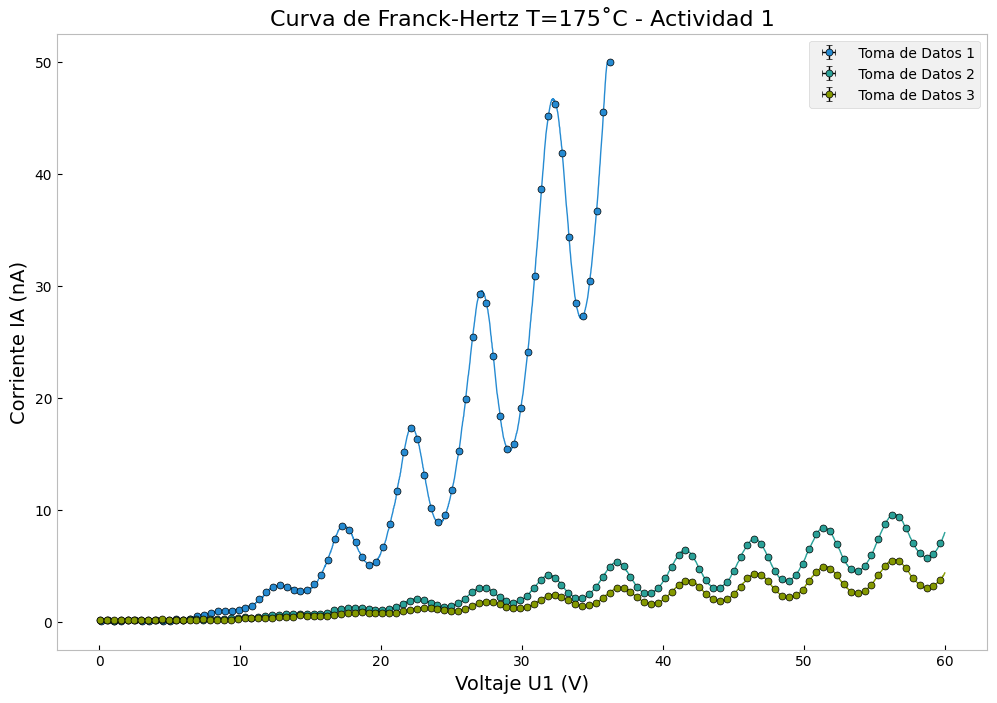

In [73]:
#Graficar Actividad_1

solarized_colors = [
    "#268BD2",  # azul
    "#2AA198",  # verde-azulado
    "#859900",  # verde amarillento
    "#CB4B16",  # naranja profundo
    "#DC322F",  # rojo
    "#B58900",  # amarillo tostado
    "#6C71C4",  # púrpura
    "#586E75"   # gris azulado
]

fig,axes = plt.subplots(1,figsize=(12,8))
axes.set_facecolor("#FFFFFF")
i=0

for df in data_ordenado.values():
    dff = df[2:-1].astype(float)
    x = dff["Voltage U1"]
    y = dff["Corriente IA"]
    
    if i==0:
        axes.errorbar(x[2:1483:20], y[2:1483:20],
            xerr=0.01, yerr=0.01,
            fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
            capsize = 2, elinewidth = 1, ecolor = 'k',
            label=f' Toma de Datos {i+1}')
        axes.plot(x[2:1483], y[2:1483], color = solarized_colors[i], linewidth = 1)
    else:
         axes.errorbar(x[2:-1:20], y[2:-1:20],
            xerr=0.01, yerr=0.01,
            fmt='o',color = solarized_colors[i] , markersize = 5, markeredgewidth = 0.5, markeredgecolor = 'k',
            capsize = 2, elinewidth = 1, ecolor = 'k',
            label=f' Toma de Datos {i+1}')
         axes.plot(x, y, color = solarized_colors[i], linewidth = 1)
    i+=1
axes.set_title("Curva de Franck-Hertz T=175˚C - Actividad 1", fontsize=16)
axes.set_xlabel("Voltaje U1 (V)", fontsize=14)
axes.set_ylabel("Corriente IA (nA)", fontsize=14)
plt.legend()
plt.grid(False)    
plt.show()

